In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        has_root_files = (candidate / "train.csv").exists() and (candidate / "test.csv").exists()
        has_data_files = (candidate / "data" / "train.csv").exists() and (candidate / "data" / "test.csv").exists()
        if has_root_files or has_data_files:
            return candidate
    raise FileNotFoundError("Could not locate project root from the current notebook working directory.")


PROJECT_ROOT = find_project_root()


def resolve_data_path(filename: str) -> Path:
    candidates = [PROJECT_ROOT / filename, PROJECT_ROOT / "data" / filename]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename} in project root or data/")


train = pd.read_csv(resolve_data_path("train.csv"), parse_dates=["date"])
test = pd.read_csv(resolve_data_path("test.csv"), parse_dates=["date"])

train_obs = train.loc[train["iv_observed"].notna()].copy()

print("Project root:", PROJECT_ROOT)
print("Train shape:", train.shape)
print("Observed-train rows:", len(train_obs))
print("Test shape:", test.shape)
print("Train date range:", train["date"].min().date(), "->", train["date"].max().date())
print("Test  date range:", test["date"].min().date(), "->", test["date"].max().date())


Project root: /Users/sauravkrishna/Documents/projects/NQFO-Impilied-volatility-surface
Train shape: (11640, 10)
Observed-train rows: 6492
Test shape: (3960, 10)
Train date range: 2025-01-02 -> 2025-05-16
Test  date range: 2025-05-19 -> 2025-07-02


In [7]:
train_date_summary = (
    train.groupby("date")
    .agg(
        total_rows=("row_id", "size"),
        observed_rows=("iv_observed", lambda s: s.notna().sum()),
        missing_rows=("iv_observed", lambda s: s.isna().sum()),
        observed_ratio=("iv_observed", lambda s: s.notna().mean()),
    )
    .sort_index()
)

display(train_date_summary.head())
display(train_date_summary.tail())
display(train_date_summary.describe().T)

train_dates = train_date_summary.index.to_list()
print("Number of train dates:", len(train_dates))


,total_rows,observed_rows,missing_rows,observed_ratio
date,,,,
2025-01-02,120,65,55,0.5417
2025-01-03,120,64,56,0.5333
2025-01-06,120,73,47,0.6083
2025-01-07,120,71,49,0.5917
2025-01-08,120,72,48,0.6000


,total_rows,observed_rows,missing_rows,observed_ratio
date,,,,
2025-05-12,120,76,44,0.6333
2025-05-13,120,70,50,0.5833
2025-05-14,120,65,55,0.5417
2025-05-15,120,73,47,0.6083
2025-05-16,120,71,49,0.5917


,count,mean,std,min,25%,50%,75%,max
total_rows,97.0000,120.0000,0.0000,120.0000,120.0000,120.0000,120.0000,120.0000
observed_rows,97.0000,66.9278,4.9228,56.0000,63.0000,67.0000,71.0000,79.0000
missing_rows,97.0000,53.0722,4.9228,41.0000,49.0000,53.0000,57.0000,64.0000
observed_ratio,97.0000,0.5577,0.0410,0.4667,0.5250,0.5583,0.5917,0.6583


Number of train dates: 97


In [8]:
N_FOLDS = 4
VAL_DATES_PER_FOLD = 5
TOTAL_VAL_DATES = N_FOLDS * VAL_DATES_PER_FOLD

assert len(train_dates) > TOTAL_VAL_DATES, "Not enough train dates for the proposed fold design."

val_start_idx = len(train_dates) - TOTAL_VAL_DATES

fold_rows = []
for fold_id in range(N_FOLDS):
    start = val_start_idx + fold_id * VAL_DATES_PER_FOLD
    end = start + VAL_DATES_PER_FOLD

    train_fold_dates = train_dates[:start]
    val_fold_dates = train_dates[start:end]

    fold_rows.append(
        {
            "fold": fold_id + 1,
            "train_start": train_fold_dates[0],
            "train_end": train_fold_dates[-1],
            "n_train_dates": len(train_fold_dates),
            "val_start": val_fold_dates[0],
            "val_end": val_fold_dates[-1],
            "n_val_dates": len(val_fold_dates),
        }
    )

fold_plan = pd.DataFrame(fold_rows)
display(fold_plan)


,fold,train_start,train_end,n_train_dates,val_start,val_end,n_val_dates
0,1,2025-01-02,2025-04-18,77,2025-04-21,2025-04-25,5
1,2,2025-01-02,2025-04-25,82,2025-04-28,2025-05-02,5
2,3,2025-01-02,2025-05-02,87,2025-05-05,2025-05-09,5
3,4,2025-01-02,2025-05-09,92,2025-05-12,2025-05-16,5


In [9]:
for row in fold_plan.itertuples(index=False):
    val_slice = train_date_summary.loc[row.val_start:row.val_end]

    print(f"\nFold {row.fold}")
    print(
        "train_dates =", row.n_train_dates,
        "| val_dates =", row.n_val_dates,
        "| val_range =", row.val_start.date(), "->", row.val_end.date(),
    )

    fold_summary = pd.Series(
        {
            "total_rows": val_slice["total_rows"].sum(),
            "observed_rows": val_slice["observed_rows"].sum(),
            "missing_rows": val_slice["missing_rows"].sum(),
            "mean_observed_ratio": val_slice["observed_ratio"].mean(),
        }
    )

    display(fold_summary.to_frame(name="value"))



Fold 1
train_dates = 77 | val_dates = 5 | val_range = 2025-04-21 -> 2025-04-25


,value
total_rows,600.0000
observed_rows,340.0000
missing_rows,260.0000
mean_observed_ratio,0.5667



Fold 2
train_dates = 82 | val_dates = 5 | val_range = 2025-04-28 -> 2025-05-02


,value
total_rows,600.0000
observed_rows,329.0000
missing_rows,271.0000
mean_observed_ratio,0.5483



Fold 3
train_dates = 87 | val_dates = 5 | val_range = 2025-05-05 -> 2025-05-09


,value
total_rows,600.0000
observed_rows,347.0000
missing_rows,253.0000
mean_observed_ratio,0.5783



Fold 4
train_dates = 92 | val_dates = 5 | val_range = 2025-05-12 -> 2025-05-16


,value
total_rows,600.0000
observed_rows,355.0000
missing_rows,245.0000
mean_observed_ratio,0.5917


In [10]:
import hashlib

BUCKET_COLS = ["maturity_label", "option_type"]
NODE_COLS = ["maturity_label", "moneyness", "option_type"]

OVERALL_TEST_MISSING_RATE = test["iv_observed"].isna().mean()
BASE_PSEUDO_HIDE_RATE = 0.25  # applied to the observed pool on validation dates

test_bucket_pattern = (
    test.assign(is_missing=test["iv_observed"].isna())
    .groupby(BUCKET_COLS)["is_missing"]
    .mean()
    .rename("test_bucket_missing_rate")
    .reset_index()
)

test_node_pattern = (
    test.assign(is_missing=test["iv_observed"].isna())
    .groupby(NODE_COLS)["is_missing"]
    .mean()
    .rename("test_node_missing_rate")
    .reset_index()
)

print("Overall test missing rate:", round(OVERALL_TEST_MISSING_RATE, 4))
print("Base pseudo-hide rate on observed validation rows:", BASE_PSEUDO_HIDE_RATE)

display(test_bucket_pattern.sort_values(BUCKET_COLS))
display(test_node_pattern.head(12))


Overall test missing rate: 0.429
Base pseudo-hide rate on observed validation rows: 0.25


,maturity_label,option_type,test_bucket_missing_rate
0,1M,call,0.4909
1,1M,put,0.4909
2,2M,call,0.4303
3,2M,put,0.4101
4,3M,call,0.3919
5,3M,put,0.4141
6,6M,call,0.3939
7,6M,put,0.4101


,maturity_label,moneyness,option_type,test_node_missing_rate
0,1M,0.8000,call,0.3636
1,1M,0.8000,put,0.4848
2,1M,0.8500,call,0.4848
3,1M,0.8500,put,0.6970
4,1M,0.8750,call,0.6061
5,1M,0.8750,put,0.5152
6,1M,0.9000,call,0.3939
7,1M,0.9000,put,0.3636
8,1M,0.9250,call,0.5152
9,1M,0.9250,put,0.3939


In [11]:
def stable_uniform(key: str) -> float:
    digest = hashlib.md5(key.encode("utf-8")).hexdigest()
    return int(digest[:12], 16) / float(16**12 - 1)


def build_masked_validation_rows(
    full_df: pd.DataFrame,
    val_dates,
    base_hide_rate: float = BASE_PSEUDO_HIDE_RATE,
    seed: str = "nqfo-val-v1",
) -> pd.DataFrame:
    val_df = full_df.loc[full_df["date"].isin(val_dates)].copy()

    val_df["is_orig_observed"] = val_df["iv_observed"].notna()
    val_df["is_orig_missing"] = ~val_df["is_orig_observed"]

    val_df = val_df.merge(test_bucket_pattern, on=BUCKET_COLS, how="left")
    val_df = val_df.merge(test_node_pattern, on=NODE_COLS, how="left")

    # Bucket-level scaling keeps the broad test structure (maturity x option_type).
    val_df["bucket_hide_rate_on_observed"] = (
        base_hide_rate * val_df["test_bucket_missing_rate"] / OVERALL_TEST_MISSING_RATE
    )

    # Node-level propensity helps choose which observed rows to hide within a bucket.
    val_df["priority_noise"] = val_df.apply(
        lambda r: stable_uniform(
            f"{seed}|{r['date'].date()}|{r['maturity_label']}|{r['moneyness']:.4f}|{r['option_type']}"
        ),
        axis=1,
    )
    val_df["mask_priority"] = val_df["test_node_missing_rate"] + 1e-6 * val_df["priority_noise"]

    val_df["is_pseudo_hidden"] = False

    observed_pool = val_df.loc[val_df["is_orig_observed"]].copy()

    for (_, _, _), g in observed_pool.groupby(["date", *BUCKET_COLS], sort=False):
        n_obs = len(g)
        hide_rate = g["bucket_hide_rate_on_observed"].iloc[0]
        n_hide = int(np.round(hide_rate * n_obs))

        if n_hide <= 0:
            continue

        chosen_idx = (
            g.sort_values(["mask_priority", "row_id"], ascending=[False, True])
            .head(n_hide)
            .index
        )
        val_df.loc[chosen_idx, "is_pseudo_hidden"] = True

    val_df["is_scored_target"] = val_df["is_pseudo_hidden"]
    val_df["is_visible_anchor"] = val_df["is_orig_observed"] & ~val_df["is_pseudo_hidden"]
    val_df["is_effectively_missing"] = val_df["is_orig_missing"] | val_df["is_pseudo_hidden"]

    return val_df.sort_values(["date", "maturity_days", "option_type", "moneyness"]).reset_index(drop=True)


In [12]:
fold1 = fold_plan.iloc[0]
fold1_val_dates = train_date_summary.loc[fold1["val_start"]:fold1["val_end"]].index.tolist()

fold1_masked = build_masked_validation_rows(train, fold1_val_dates)

display(
    fold1_masked[
        [
            "row_id", "date", "moneyness", "option_type", "maturity_label",
            "iv_observed", "is_orig_observed", "is_orig_missing",
            "is_pseudo_hidden", "is_visible_anchor", "is_scored_target",
            "is_effectively_missing"
        ]
    ].head(15)
)

fold1_date_summary = (
    fold1_masked.groupby("date")
    .agg(
        total_rows=("row_id", "size"),
        orig_observed=("is_orig_observed", "sum"),
        orig_missing=("is_orig_missing", "sum"),
        pseudo_hidden=("is_pseudo_hidden", "sum"),
        visible_anchors=("is_visible_anchor", "sum"),
        scored_targets=("is_scored_target", "sum"),
        effective_missing_rate=("is_effectively_missing", "mean"),
        visible_anchor_rate=("is_visible_anchor", "mean"),
    )
    .sort_index()
)

display(fold1_date_summary)

print("Fold 1 totals")
display(
    pd.Series(
        {
            "total_rows": len(fold1_masked),
            "orig_observed": int(fold1_masked["is_orig_observed"].sum()),
            "orig_missing": int(fold1_masked["is_orig_missing"].sum()),
            "pseudo_hidden": int(fold1_masked["is_pseudo_hidden"].sum()),
            "visible_anchors": int(fold1_masked["is_visible_anchor"].sum()),
            "scored_targets": int(fold1_masked["is_scored_target"].sum()),
            "effective_missing_rate": fold1_masked["is_effectively_missing"].mean(),
            "visible_anchor_rate": fold1_masked["is_visible_anchor"].mean(),
        }
    ).to_frame(name="value")
)


,row_id,date,moneyness,option_type,maturity_label,iv_observed,is_orig_observed,is_orig_missing,is_pseudo_hidden,is_visible_anchor,is_scored_target,is_effectively_missing
0,9240,2025-04-21,0.8000,call,1M,25.0399,True,False,False,True,False,False
1,9242,2025-04-21,0.8500,call,1M,NaN,False,True,False,False,False,True
2,9244,2025-04-21,0.8750,call,1M,NaN,False,True,False,False,False,True
3,9246,2025-04-21,0.9000,call,1M,21.4052,True,False,False,True,False,False
4,9248,2025-04-21,0.9250,call,1M,21.7396,True,False,True,False,True,True
5,9250,2025-04-21,0.9500,call,1M,21.3998,True,False,False,True,False,False
6,9252,2025-04-21,0.9750,call,1M,20.2565,True,False,False,True,False,False
7,9254,2025-04-21,1.0000,call,1M,20.1230,True,False,False,True,False,False
8,9256,2025-04-21,1.0250,call,1M,NaN,False,True,False,False,False,True
9,9258,2025-04-21,1.0500,call,1M,20.3644,True,False,False,True,False,False


,total_rows,orig_observed,orig_missing,pseudo_hidden,visible_anchors,scored_targets,effective_missing_rate,visible_anchor_rate
date,,,,,,,,
2025-04-21,120,77,43,20,57,20,0.5250,0.4750
2025-04-22,120,60,60,15,45,15,0.6250,0.3750
2025-04-23,120,61,59,14,47,14,0.6083,0.3917
2025-04-24,120,76,44,19,57,19,0.5250,0.4750
2025-04-25,120,66,54,17,49,17,0.5917,0.4083


Fold 1 totals


,value
total_rows,600.0000
orig_observed,340.0000
orig_missing,260.0000
pseudo_hidden,85.0000
visible_anchors,255.0000
scored_targets,85.0000
effective_missing_rate,0.5750
visible_anchor_rate,0.4250


In [13]:
fold1_bucket_summary = (
    fold1_masked.groupby(BUCKET_COLS)
    .agg(
        total_rows=("row_id", "size"),
        orig_observed=("is_orig_observed", "sum"),
        orig_missing=("is_orig_missing", "sum"),
        pseudo_hidden=("is_pseudo_hidden", "sum"),
        visible_anchors=("is_visible_anchor", "sum"),
        effective_missing_rate=("is_effectively_missing", "mean"),
    )
    .reset_index()
)

fold1_bucket_summary["pseudo_hidden_rate_on_observed"] = (
    fold1_bucket_summary["pseudo_hidden"] / fold1_bucket_summary["orig_observed"]
)

bucket_comparison = (
    test_bucket_pattern.merge(fold1_bucket_summary, on=BUCKET_COLS, how="left")
    .sort_values(BUCKET_COLS)
)

display(bucket_comparison)

print("Overall comparison")
display(
    pd.Series(
        {
            "test_missing_rate_overall": OVERALL_TEST_MISSING_RATE,
            "fold1_pseudo_hidden_rate_on_observed": fold1_masked["is_pseudo_hidden"].sum() / fold1_masked["is_orig_observed"].sum(),
            "fold1_visible_anchor_rate_overall": fold1_masked["is_visible_anchor"].mean(),
            "fold1_effective_missing_rate_overall": fold1_masked["is_effectively_missing"].mean(),
        }
    ).to_frame(name="value")
)


,maturity_label,option_type,test_bucket_missing_rate,total_rows,orig_observed,orig_missing,pseudo_hidden,visible_anchors,effective_missing_rate,pseudo_hidden_rate_on_observed
0,1M,call,0.4909,75,42,33,12,30,0.6000,0.2857
1,1M,put,0.4909,75,42,33,12,30,0.6000,0.2857
2,2M,call,0.4303,75,42,33,12,30,0.6000,0.2857
3,2M,put,0.4101,75,40,35,8,32,0.5733,0.2000
4,3M,call,0.3919,75,47,28,11,36,0.5200,0.2340
5,3M,put,0.4141,75,47,28,11,36,0.5200,0.2340
6,6M,call,0.3939,75,37,38,8,29,0.6133,0.2162
7,6M,put,0.4101,75,43,32,11,32,0.5733,0.2558


Overall comparison


,value
test_missing_rate_overall,0.4290
fold1_pseudo_hidden_rate_on_observed,0.2500
fold1_visible_anchor_rate_overall,0.4250
fold1_effective_missing_rate_overall,0.5750


In [14]:
candidate_hide_rates = [0.05, 0.10, 0.15, 0.20, 0.25]

sweep_rows = []

for base_rate in candidate_hide_rates:
    for row in fold_plan.itertuples(index=False):
        val_dates = train_date_summary.loc[row.val_start:row.val_end].index.tolist()
        masked = build_masked_validation_rows(train, val_dates, base_hide_rate=base_rate)

        sweep_rows.append(
            {
                "base_hide_rate": base_rate,
                "fold": row.fold,
                "orig_observed": int(masked["is_orig_observed"].sum()),
                "orig_missing": int(masked["is_orig_missing"].sum()),
                "pseudo_hidden": int(masked["is_pseudo_hidden"].sum()),
                "visible_anchors": int(masked["is_visible_anchor"].sum()),
                "scored_targets": int(masked["is_scored_target"].sum()),
                "effective_missing_rate": masked["is_effectively_missing"].mean(),
                "visible_anchor_rate": masked["is_visible_anchor"].mean(),
                "pseudo_hidden_rate_on_observed": masked["is_pseudo_hidden"].sum() / masked["is_orig_observed"].sum(),
            }
        )

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)


,base_hide_rate,fold,orig_observed,orig_missing,pseudo_hidden,visible_anchors,scored_targets,effective_missing_rate,visible_anchor_rate,pseudo_hidden_rate_on_observed
0,0.0500,1,340,260,10,330,10,0.4500,0.5500,0.0294
1,0.0500,2,329,271,7,322,7,0.4633,0.5367,0.0213
2,0.0500,3,347,253,11,336,11,0.4400,0.5600,0.0317
3,0.0500,4,355,245,14,341,14,0.4317,0.5683,0.0394
4,0.1000,1,340,260,39,301,39,0.4983,0.5017,0.1147
5,0.1000,2,329,271,38,291,38,0.5150,0.4850,0.1155
6,0.1000,3,347,253,39,308,39,0.4867,0.5133,0.1124
7,0.1000,4,355,245,40,315,40,0.4750,0.5250,0.1127
8,0.1500,1,340,260,50,290,50,0.5167,0.4833,0.1471
9,0.1500,2,329,271,47,282,47,0.5300,0.4700,0.1429


In [15]:
sweep_summary = (
    sweep_df.groupby("base_hide_rate")
    .agg(
        mean_scored_targets=("scored_targets", "mean"),
        min_scored_targets=("scored_targets", "min"),
        mean_visible_anchor_rate=("visible_anchor_rate", "mean"),
        min_visible_anchor_rate=("visible_anchor_rate", "min"),
        mean_effective_missing_rate=("effective_missing_rate", "mean"),
        max_effective_missing_rate=("effective_missing_rate", "max"),
        mean_pseudo_hidden_rate_on_observed=("pseudo_hidden_rate_on_observed", "mean"),
    )
    .round(4)
)

display(sweep_summary)

print("Real test reference")
display(
    pd.Series(
        {
            "test_missing_rate_overall": test["iv_observed"].isna().mean(),
            "test_visible_rate_overall": test["iv_observed"].notna().mean(),
        }
    ).to_frame(name="value")
)


,mean_scored_targets,min_scored_targets,mean_visible_anchor_rate,min_visible_anchor_rate,mean_effective_missing_rate,max_effective_missing_rate,mean_pseudo_hidden_rate_on_observed
base_hide_rate,,,,,,,
0.0500,10.5000,7,0.5538,0.5367,0.4462,0.4633,0.0305
0.1000,39.0000,38,0.5062,0.4850,0.4938,0.5150,0.1138
0.1500,50.5000,47,0.4871,0.4700,0.5129,0.5300,0.1473
0.2000,69.5000,69,0.4554,0.4333,0.5446,0.5667,0.2029
0.2500,86.0000,82,0.4279,0.4117,0.5721,0.5883,0.2509


Real test reference


,value
test_missing_rate_overall,0.4290
test_visible_rate_overall,0.5710


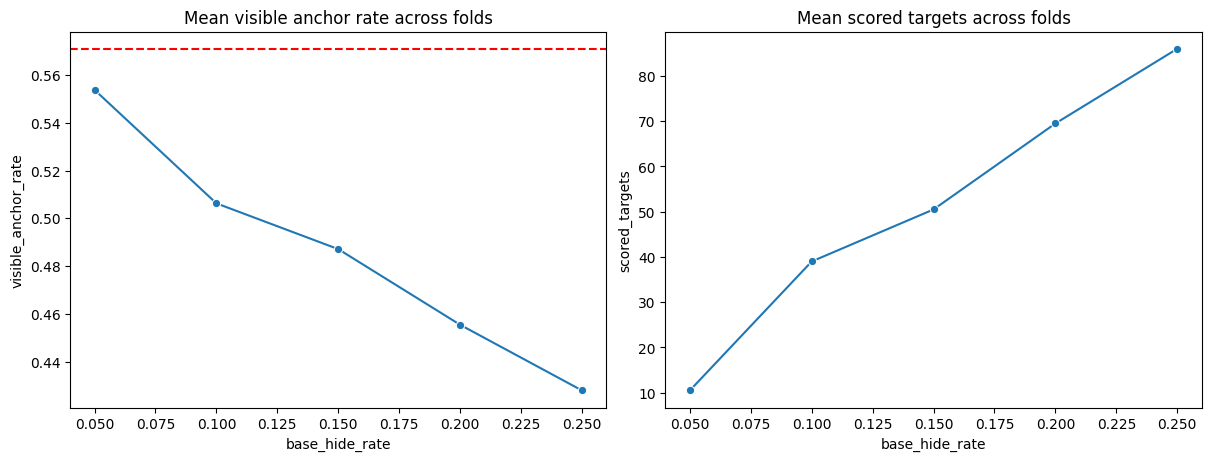

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

sns.lineplot(
    data=sweep_df,
    x="base_hide_rate",
    y="visible_anchor_rate",
    marker="o",
    estimator="mean",
    errorbar=None,
    ax=axes[0],
)
axes[0].axhline(test["iv_observed"].notna().mean(), linestyle="--", color="red")
axes[0].set_title("Mean visible anchor rate across folds")
axes[0].set_ylabel("visible_anchor_rate")

sns.lineplot(
    data=sweep_df,
    x="base_hide_rate",
    y="scored_targets",
    marker="o",
    estimator="mean",
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Mean scored targets across folds")
axes[1].set_ylabel("scored_targets")

plt.show()


In [17]:
LOCKED_BASE_HIDE_RATE = 0.10
LOCKED_MASK_SEED = "nqfo-val-v1"

print("Locked validation settings")
print("LOCKED_BASE_HIDE_RATE =", LOCKED_BASE_HIDE_RATE)
print("LOCKED_MASK_SEED =", LOCKED_MASK_SEED)


Locked validation settings
LOCKED_BASE_HIDE_RATE = 0.1
LOCKED_MASK_SEED = nqfo-val-v1


In [18]:
def make_fold_bundle(train_df: pd.DataFrame, fold_row, seed: str = LOCKED_MASK_SEED, base_hide_rate: float = LOCKED_BASE_HIDE_RATE):
    val_dates = train_date_summary.loc[fold_row.val_start:fold_row.val_end].index.tolist()
    train_dates = train_date_summary.loc[:fold_row.train_end].index.tolist()

    train_history = train_df.loc[train_df["date"].isin(train_dates)].copy()
    val_masked = build_masked_validation_rows(train_df, val_dates, base_hide_rate=base_hide_rate, seed=seed)

    bundle = {
        "fold": fold_row.fold,
        "train_dates": train_dates,
        "val_dates": val_dates,
        "train_history": train_history,
        "val_masked": val_masked,
        "val_visible_anchors": val_masked.loc[val_masked["is_visible_anchor"]].copy(),
        "val_scored_targets": val_masked.loc[val_masked["is_scored_target"]].copy(),
        "val_orig_missing": val_masked.loc[val_masked["is_orig_missing"]].copy(),
    }
    return bundle


fold_bundles = [
    make_fold_bundle(train, row)
    for row in fold_plan.itertuples(index=False)
]


In [19]:
bundle_summary_rows = []

for bundle in fold_bundles:
    val_masked = bundle["val_masked"]
    bundle_summary_rows.append(
        {
            "fold": bundle["fold"],
            "n_train_rows": len(bundle["train_history"]),
            "n_val_rows": len(val_masked),
            "n_val_dates": len(bundle["val_dates"]),
            "visible_anchors": int(val_masked["is_visible_anchor"].sum()),
            "scored_targets": int(val_masked["is_scored_target"].sum()),
            "orig_missing": int(val_masked["is_orig_missing"].sum()),
            "visible_anchor_rate": val_masked["is_visible_anchor"].mean(),
            "effective_missing_rate": val_masked["is_effectively_missing"].mean(),
        }
    )

bundle_summary = pd.DataFrame(bundle_summary_rows)
display(bundle_summary)

print("Aggregate validation summary")
display(
    bundle_summary.agg(
        {
            "visible_anchors": ["mean", "min", "max"],
            "scored_targets": ["mean", "min", "max"],
            "visible_anchor_rate": ["mean", "min", "max"],
            "effective_missing_rate": ["mean", "min", "max"],
        }
    ).round(4)
)


,fold,n_train_rows,n_val_rows,n_val_dates,visible_anchors,scored_targets,orig_missing,visible_anchor_rate,effective_missing_rate
0,1,9240,600,5,301,39,260,0.5017,0.4983
1,2,9840,600,5,291,38,271,0.4850,0.5150
2,3,10440,600,5,308,39,253,0.5133,0.4867
3,4,11040,600,5,315,40,245,0.5250,0.4750


Aggregate validation summary


,visible_anchors,scored_targets,visible_anchor_rate,effective_missing_rate
mean,303.7500,39.0000,0.5062,0.4938
min,291.0000,38.0000,0.4850,0.4750
max,315.0000,40.0000,0.5250,0.5150


In [20]:
example_fold = fold_bundles[0]

print("Fold", example_fold["fold"])
print("Train history date range:", example_fold["train_dates"][0].date(), "->", example_fold["train_dates"][-1].date())
print("Validation date range:", example_fold["val_dates"][0].date(), "->", example_fold["val_dates"][-1].date())

display(example_fold["val_visible_anchors"].head(10))
display(example_fold["val_scored_targets"].head(10))


Fold 1
Train history date range: 2025-01-02 -> 2025-04-18
Validation date range: 2025-04-21 -> 2025-04-25


,row_id,date,spot,strike,moneyness,option_type,maturity_label,maturity_days,tau,iv_observed,is_orig_observed,is_orig_missing,test_bucket_missing_rate,test_node_missing_rate,bucket_hide_rate_on_observed,priority_noise,mask_priority,is_pseudo_hidden,is_scored_target,is_visible_anchor,is_effectively_missing
0,9240,2025-04-21,"20,616.7900",16500,0.8000,call,1M,30,0.1191,25.0399,True,False,0.4909,0.3636,0.1144,0.3033,0.3636,False,False,True,False
3,9246,2025-04-21,"20,616.7900",18550,0.9000,call,1M,30,0.1191,21.4052,True,False,0.4909,0.3939,0.1144,0.1060,0.3939,False,False,True,False
4,9248,2025-04-21,"20,616.7900",19050,0.9250,call,1M,30,0.1191,21.7396,True,False,0.4909,0.5152,0.1144,0.6441,0.5152,False,False,True,False
5,9250,2025-04-21,"20,616.7900",19600,0.9500,call,1M,30,0.1191,21.3998,True,False,0.4909,0.4848,0.1144,0.2663,0.4848,False,False,True,False
6,9252,2025-04-21,"20,616.7900",20100,0.9750,call,1M,30,0.1191,20.2565,True,False,0.4909,0.4848,0.1144,0.5530,0.4848,False,False,True,False
7,9254,2025-04-21,"20,616.7900",20600,1.0000,call,1M,30,0.1191,20.1230,True,False,0.4909,0.4848,0.1144,0.9418,0.4848,False,False,True,False
9,9258,2025-04-21,"20,616.7900",21650,1.0500,call,1M,30,0.1191,20.3644,True,False,0.4909,0.4545,0.1144,0.9661,0.4545,False,False,True,False
10,9260,2025-04-21,"20,616.7900",22150,1.0750,call,1M,30,0.1191,19.4929,True,False,0.4909,0.3333,0.1144,0.4309,0.3333,False,False,True,False
12,9264,2025-04-21,"20,616.7900",23200,1.1250,call,1M,30,0.1191,19.2972,True,False,0.4909,0.6061,0.1144,0.1498,0.6061,False,False,True,False
17,9245,2025-04-21,"20,616.7900",18050,0.8750,put,1M,30,0.1191,24.2840,True,False,0.4909,0.5152,0.1144,0.6405,0.5152,False,False,True,False


,row_id,date,spot,strike,moneyness,option_type,maturity_label,maturity_days,tau,iv_observed,is_orig_observed,is_orig_missing,test_bucket_missing_rate,test_node_missing_rate,bucket_hide_rate_on_observed,priority_noise,mask_priority,is_pseudo_hidden,is_scored_target,is_visible_anchor,is_effectively_missing
11,9262,2025-04-21,"20,616.7900",22700,1.1000,call,1M,30,0.1191,19.2304,True,False,0.4909,0.6667,0.1144,0.2460,0.6667,True,True,False,True
16,9243,2025-04-21,"20,616.7900",17500,0.8500,put,1M,30,0.1191,26.2571,True,False,0.4909,0.6970,0.1144,0.9566,0.6970,True,True,False,True
43,9296,2025-04-21,"20,616.7900",23700,1.1500,call,2M,60,0.2381,17.9204,True,False,0.4303,0.6061,0.1003,0.3220,0.6061,True,True,False,True
45,9271,2025-04-21,"20,616.7900",16500,0.8000,put,2M,60,0.2381,25.9285,True,False,0.4101,0.6667,0.0956,0.5774,0.6667,True,True,False,True
66,9312,2025-04-21,"20,616.7900",20100,0.9750,call,3M,91,0.3611,18.7062,True,False,0.3919,0.5152,0.0913,0.5301,0.5152,True,True,False,True
89,9329,2025-04-21,"20,616.7900",24750,1.2000,put,3M,91,0.3611,16.8226,True,False,0.4141,0.5455,0.0965,0.8644,0.5455,True,True,False,True
97,9344,2025-04-21,"20,616.7900",20600,1.0000,call,6M,182,0.7222,17.1591,True,False,0.3939,0.4242,0.0918,0.3081,0.4242,True,True,False,True
107,9335,2025-04-21,"20,616.7900",18050,0.8750,put,6M,182,0.7222,19.1196,True,False,0.4101,0.5758,0.0956,0.2755,0.5758,True,True,False,True
126,9372,2025-04-22,"20,647.7600",20150,0.9750,call,1M,30,0.1191,21.0011,True,False,0.4909,0.4848,0.1144,0.8034,0.4848,True,True,False,True
136,9363,2025-04-22,"20,647.7600",17550,0.8500,put,1M,30,0.1191,26.2953,True,False,0.4909,0.6970,0.1144,0.9434,0.6970,True,True,False,True


In [21]:
from sklearn.metrics import mean_squared_error


def rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def score_predictions(scored_df: pd.DataFrame, pred_col: str = "iv_pred") -> dict:
    assert pred_col in scored_df.columns, f"Missing prediction column: {pred_col}"

    eval_df = scored_df.loc[scored_df["is_scored_target"]].copy()
    eval_df = eval_df.loc[eval_df["iv_observed"].notna()].copy()
    eval_df = eval_df.loc[eval_df[pred_col].notna()].copy()

    return {
        "n_scored": len(eval_df),
        "rmse": rmse(eval_df["iv_observed"], eval_df[pred_col]),
    }


In [22]:
def add_basic_eval_buckets(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["moneyness_bucket"] = pd.cut(
        out["moneyness"],
        bins=[-np.inf, 0.9, 1.1, np.inf],
        labels=["left_wing", "center", "right_wing"],
    )

    out["anchor_support_bucket"] = np.where(
        out["is_scored_target"],
        np.where(
            out["test_node_missing_rate"] >= 0.55,
            "harder_pattern",
            "easier_pattern",
        ),
        "not_scored",
    )

    return out


def score_breakdowns(scored_df: pd.DataFrame, pred_col: str = "iv_pred") -> dict:
    eval_df = add_basic_eval_buckets(scored_df)
    eval_df = eval_df.loc[eval_df["is_scored_target"]].copy()
    eval_df = eval_df.loc[eval_df["iv_observed"].notna() & eval_df[pred_col].notna()].copy()

    breakdowns = {}

    for group_col in ["maturity_label", "option_type", "moneyness_bucket", "anchor_support_bucket", "date"]:
        part = (
            eval_df.groupby(group_col)
            .apply(lambda g: pd.Series({"n": len(g), "rmse": rmse(g["iv_observed"], g[pred_col])}))
            .reset_index()
            .sort_values(group_col)
        )
        breakdowns[group_col] = part

    return breakdowns


In [23]:
def naive_demo_predictor(val_masked: pd.DataFrame) -> pd.DataFrame:
    demo = val_masked.copy()

    # Deliberately simple benchmark: predict each scored row using the mean visible anchor IV
    # from the same date. This is only to validate the evaluation plumbing.
    date_anchor_mean = (
        demo.loc[demo["is_visible_anchor"]]
        .groupby("date")["iv_observed"]
        .mean()
        .rename("date_anchor_mean")
    )

    global_anchor_mean = demo.loc[demo["is_visible_anchor"], "iv_observed"].mean()

    demo = demo.merge(date_anchor_mean, on="date", how="left")
    demo["iv_pred"] = demo["date_anchor_mean"].fillna(global_anchor_mean)

    return demo


demo_fold = fold_bundles[0]["val_masked"]
demo_scored = naive_demo_predictor(demo_fold)

demo_score = score_predictions(demo_scored, pred_col="iv_pred")
print("Demo fold score")
display(pd.Series(demo_score).to_frame(name="value"))

demo_breakdowns = score_breakdowns(demo_scored, pred_col="iv_pred")
for key, table in demo_breakdowns.items():
    print(f"\nBreakdown by {key}")
    display(table.head(10))


Demo fold score


,value
n_scored,39.0000
rmse,3.3265



Breakdown by maturity_label


/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/768161159.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"n": len(g), "rmse": rmse(g["iv_observed"], g[pred_col])}))
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/768161159.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"n": len(g), "rmse": rmse(g["iv_observ

,maturity_label,n,rmse
0,1M,10.0000,4.0260
1,2M,10.0000,4.3524
2,3M,10.0000,2.1614
3,6M,9.0000,1.9243


...

,moneyness_bucket,n,rmse
0,left_wing,15.0000,4.6993
1,center,10.0000,1.3096
2,right_wing,14.0000,2.4371



Breakdown by anchor_support_bucket


,anchor_support_bucket,n,rmse
0,easier_pattern,19.0000,2.1430
1,harder_pattern,20.0000,4.1491



Breakdown by date


,date,n,rmse
0,2025-04-21,8.0000,3.5481
1,2025-04-22,8.0000,3.9523
2,2025-04-23,7.0000,3.6839
3,2025-04-24,8.0000,2.7581
4,2025-04-25,8.0000,2.5007


In [24]:
fold_eval_rows = []

for bundle in fold_bundles:
    scored = naive_demo_predictor(bundle["val_masked"])
    metrics = score_predictions(scored, pred_col="iv_pred")

    fold_eval_rows.append(
        {
            "fold": bundle["fold"],
            "n_scored": metrics["n_scored"],
            "rmse": metrics["rmse"],
        }
    )

fold_eval_df = pd.DataFrame(fold_eval_rows)
display(fold_eval_df)

print("Cross-fold demo summary")
display(
    fold_eval_df.agg(
        {
            "n_scored": ["mean", "min", "max"],
            "rmse": ["mean", "min", "max"],
        }
    ).round(4)
)


,fold,n_scored,rmse
0,1,39,3.3265
1,2,38,3.2047
2,3,39,2.9555
3,4,40,3.1764


Cross-fold demo summary


,n_scored,rmse
mean,39.0000,3.1658
min,38.0000,2.9555
max,40.0000,3.3265


In [25]:
# --- Phase 2.5 / Cell 1: support-profile helpers ---

SURFACE_COLS = ["date", "moneyness", "maturity_label", "option_type"]

all_surface_levels = pd.concat(
    [
        train[["moneyness", "maturity_label", "maturity_days"]],
        test[["moneyness", "maturity_label", "maturity_days"]],
    ],
    ignore_index=True,
)

moneyness_levels = sorted(all_surface_levels["moneyness"].dropna().unique().tolist())
maturity_levels = (
    all_surface_levels[["maturity_label", "maturity_days"]]
    .drop_duplicates()
    .sort_values("maturity_days")["maturity_label"]
    .tolist()
)

m_idx = {m: i for i, m in enumerate(moneyness_levels)}
t_idx = {t: i for i, t in enumerate(maturity_levels)}


def opposite_option(opt: str) -> str:
    return "put" if opt == "call" else "call"


def build_support_profile(target_rows: pd.DataFrame, visible_rows: pd.DataFrame) -> pd.DataFrame:
    prof = target_rows.copy()

    visible_key_set = set(
        zip(
            visible_rows["date"],
            visible_rows["moneyness"],
            visible_rows["maturity_label"],
            visible_rows["option_type"],
        )
    )

    opp_visible = []
    same_maturity_adj_count = []
    same_moneyness_adj_count = []

    for d, m, t, o in zip(
        prof["date"],
        prof["moneyness"],
        prof["maturity_label"],
        prof["option_type"],
    ):
        opp_visible.append((d, m, t, opposite_option(o)) in visible_key_set)

        i = m_idx[m]
        j = t_idx[t]

        same_maturity_candidates = []
        if i - 1 >= 0:
            same_maturity_candidates.append((d, moneyness_levels[i - 1], t, o))
        if i + 1 < len(moneyness_levels):
            same_maturity_candidates.append((d, moneyness_levels[i + 1], t, o))

        same_moneyness_candidates = []
        if j - 1 >= 0:
            same_moneyness_candidates.append((d, m, maturity_levels[j - 1], o))
        if j + 1 < len(maturity_levels):
            same_moneyness_candidates.append((d, m, maturity_levels[j + 1], o))

        same_maturity_adj_count.append(sum(c in visible_key_set for c in same_maturity_candidates))
        same_moneyness_adj_count.append(sum(c in visible_key_set for c in same_moneyness_candidates))

    prof["opp_option_visible"] = opp_visible
    prof["same_maturity_adj_visible_count"] = same_maturity_adj_count
    prof["same_moneyness_adj_visible_count"] = same_moneyness_adj_count

    prof["any_local_same_date_support"] = (
        prof["opp_option_visible"]
        | (prof["same_maturity_adj_visible_count"] > 0)
        | (prof["same_moneyness_adj_visible_count"] > 0)
    )

    prof["hard_case"] = ~prof["any_local_same_date_support"]
    return prof


def support_metric_series(df: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "n_targets": len(df),
            "opp_option_visible_rate": df["opp_option_visible"].mean(),
            "same_maturity_adj_visible_rate": (df["same_maturity_adj_visible_count"] > 0).mean(),
            "same_moneyness_adj_visible_rate": (df["same_moneyness_adj_visible_count"] > 0).mean(),
            "any_local_same_date_support_rate": df["any_local_same_date_support"].mean(),
            "hard_case_rate": df["hard_case"].mean(),
        }
    ).round(4)


def support_summary_by_group(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    tmp = df.copy()
    tmp["same_maturity_adj_visible"] = tmp["same_maturity_adj_visible_count"] > 0
    tmp["same_moneyness_adj_visible"] = tmp["same_moneyness_adj_visible_count"] > 0

    out = (
        tmp.groupby(group_col)
        .agg(
            n_targets=("row_id", "size"),
            opp_option_visible_rate=("opp_option_visible", "mean"),
            same_maturity_adj_visible_rate=("same_maturity_adj_visible", "mean"),
            same_moneyness_adj_visible_rate=("same_moneyness_adj_visible", "mean"),
            any_local_same_date_support_rate=("any_local_same_date_support", "mean"),
            hard_case_rate=("hard_case", "mean"),
        )
        .reset_index()
        .round(4)
    )
    return out


In [26]:
# --- Phase 2.5 / Cell 2: compute support profiles for test and validation pseudo-targets ---

test_visible_rows = test.loc[test["iv_observed"].notna()].copy()
test_missing_targets = test.loc[test["iv_observed"].isna()].copy()

test_support_profile = build_support_profile(test_missing_targets, test_visible_rows)

val_support_profiles = []
fold_support_rows = []

for bundle in fold_bundles:
    fold_profile = build_support_profile(
        bundle["val_scored_targets"],
        bundle["val_visible_anchors"],
    ).copy()

    fold_profile["fold"] = bundle["fold"]
    val_support_profiles.append(fold_profile)

    fold_support_rows.append(
        {
            "fold": bundle["fold"],
            **support_metric_series(fold_profile).to_dict(),
        }
    )

pooled_val_support_profile = pd.concat(val_support_profiles, ignore_index=True)

fold_support_summary = pd.DataFrame(fold_support_rows).round(4)

pooled_comparison = pd.DataFrame(
    [
        {
            "group": "actual_missing_test_targets",
            **support_metric_series(test_support_profile).to_dict(),
        },
        {
            "group": "pooled_validation_pseudo_targets",
            **support_metric_series(pooled_val_support_profile).to_dict(),
        },
    ]
).set_index("group")

rate_cols = [
    "opp_option_visible_rate",
    "same_maturity_adj_visible_rate",
    "same_moneyness_adj_visible_rate",
    "any_local_same_date_support_rate",
    "hard_case_rate",
]

comparison_delta = (
    pooled_comparison.loc["pooled_validation_pseudo_targets", rate_cols]
    - pooled_comparison.loc["actual_missing_test_targets", rate_cols]
).rename("val_minus_test").to_frame()

test_by_maturity = support_summary_by_group(test_support_profile, "maturity_label")
val_by_maturity = support_summary_by_group(pooled_val_support_profile, "maturity_label")

by_maturity_comparison = test_by_maturity.merge(
    val_by_maturity,
    on="maturity_label",
    suffixes=("_test", "_val"),
)

for col in rate_cols:
    by_maturity_comparison[f"{col}_delta"] = (
        by_maturity_comparison[f"{col}_val"] - by_maturity_comparison[f"{col}_test"]
    ).round(4)


In [27]:
# --- Phase 2.5 / Cell 3: display the audit tables ---

print("=== FOLD-BY-FOLD VALIDATION PSEUDO-TARGET SUPPORT SUMMARY ===")
display(fold_support_summary)

print("=== DIRECT COMPARISON: TEST MISSING TARGETS VS POOLED VALIDATION PSEUDO-TARGETS ===")
display(pooled_comparison)

print("=== RATE DIFFERENCES: VALIDATION MINUS TEST ===")
display(comparison_delta)

print("=== BY-MATURITY SUPPORT SUMMARY: TEST MISSING TARGETS ===")
display(test_by_maturity)

print("=== BY-MATURITY SUPPORT SUMMARY: POOLED VALIDATION PSEUDO-TARGETS ===")
display(val_by_maturity)

print("=== BY-MATURITY COMPARISON WITH DELTAS ===")
display(by_maturity_comparison)


=== FOLD-BY-FOLD VALIDATION PSEUDO-TARGET SUPPORT SUMMARY ===


,fold,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1,39.0000,0.5385,0.5641,0.6410,0.9231,0.0769
1,2,38.0000,0.4211,0.6316,0.6579,0.9474,0.0526
2,3,39.0000,0.4359,0.6923,0.6154,0.9487,0.0513
3,4,40.0000,0.3250,0.6500,0.5750,0.8250,0.1750


=== DIRECT COMPARISON: TEST MISSING TARGETS VS POOLED VALIDATION PSEUDO-TARGETS ===


,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
group,,,,,,
actual_missing_test_targets,"1,699.0000",0.5715,0.7793,0.6786,0.9647,0.0353
pooled_validation_pseudo_targets,156.0000,0.4295,0.6346,0.6218,0.9103,0.0897


=== RATE DIFFERENCES: VALIDATION MINUS TEST ===


...

,maturity_label,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1M,486,0.5144,0.7366,0.5802,0.9321,0.0679
1,2M,416,0.5625,0.7764,0.7812,0.9904,0.0096
2,3M,399,0.6341,0.7945,0.7970,0.9774,0.0226
3,6M,398,0.5879,0.8191,0.5729,0.9648,0.0352


=== BY-MATURITY SUPPORT SUMMARY: POOLED VALIDATION PSEUDO-TARGETS ===


,maturity_label,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1M,40,0.3750,0.6000,0.4000,0.8500,0.1500
1,2M,39,0.3590,0.4359,0.7179,0.9487,0.0513
2,3M,39,0.6154,0.7436,0.8205,0.9744,0.0256
3,6M,38,0.3684,0.7632,0.5526,0.8684,0.1316


=== BY-MATURITY COMPARISON WITH DELTAS ===


,maturity_label,n_targets_test,opp_option_visible_rate_test,same_maturity_adj_visible_rate_test,same_moneyness_adj_visible_rate_test,any_local_same_date_support_rate_test,hard_case_rate_test,n_targets_val,opp_option_visible_rate_val,same_maturity_adj_visible_rate_val,same_moneyness_adj_visible_rate_val,any_local_same_date_support_rate_val,hard_case_rate_val,opp_option_visible_rate_delta,same_maturity_adj_visible_rate_delta,same_moneyness_adj_visible_rate_delta,any_local_same_date_support_rate_delta,hard_case_rate_delta
0,1M,486,0.5144,0.7366,0.5802,0.9321,0.0679,40,0.3750,0.6000,0.4000,0.8500,0.1500,-0.1394,-0.1366,-0.1802,-0.0821,0.0821
1,2M,416,0.5625,0.7764,0.7812,0.9904,0.0096,39,0.3590,0.4359,0.7179,0.9487,0.0513,-0.2035,-0.3405,-0.0633,-0.0417,0.0417
2,3M,399,0.6341,0.7945,0.7970,0.9774,0.0226,39,0.6154,0.7436,0.8205,0.9744,0.0256,-0.0187,-0.0509,0.0235,-0.0030,0.0030
3,6M,398,0.5879,0.8191,0.5729,0.9648,0.0352,38,0.3684,0.7632,0.5526,0.8684,0.1316,-0.2195,-0.0559,-0.0203,-0.0964,0.0964


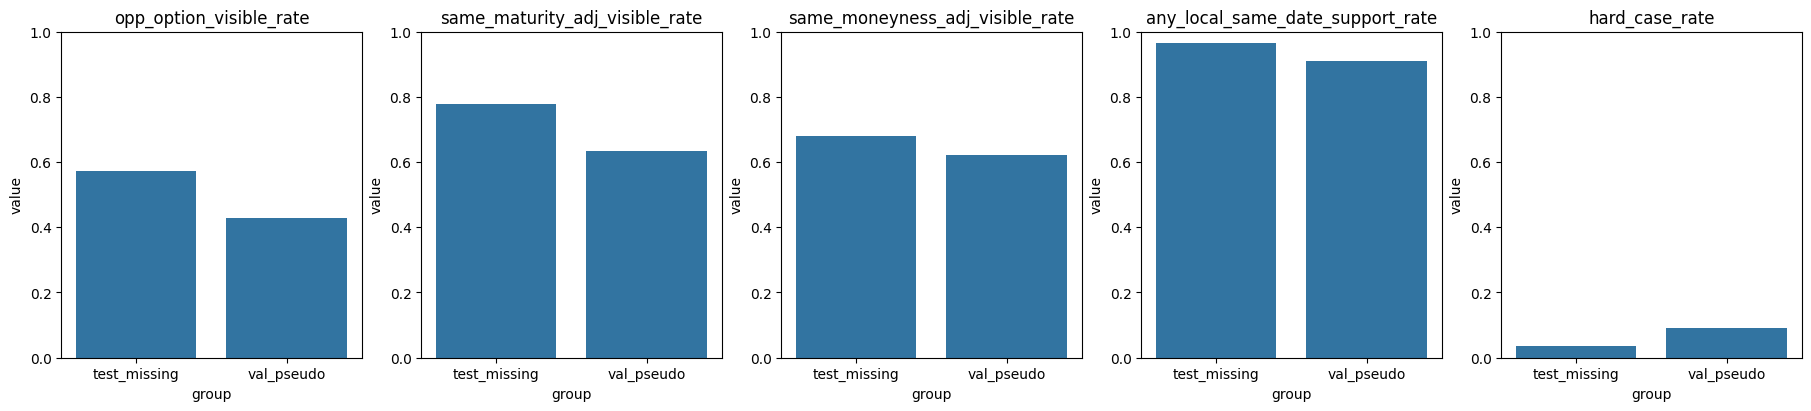

In [28]:
# --- Phase 2.5 / Cell 4: optional quick visual check ---

fig, axes = plt.subplots(1, len(rate_cols), figsize=(18, 4), constrained_layout=True)

for ax, col in zip(axes, rate_cols):
    compare_plot = pd.DataFrame(
        {
            "group": ["test_missing", "val_pseudo"],
            "value": [
                pooled_comparison.loc["actual_missing_test_targets", col],
                pooled_comparison.loc["pooled_validation_pseudo_targets", col],
            ],
        }
    )
    sns.barplot(data=compare_plot, x="group", y="value", ax=ax)
    ax.set_title(col)
    ax.set_ylim(0, 1)

plt.show()


In [29]:
# --- Phase 2.6 / Cell 1: add a softer primary masking protocol ---

MASK_PROTOCOL_CONFIG = {
    "stress_test": {
        "base_hide_rate": LOCKED_BASE_HIDE_RATE,
        "node_weight": 1.00,
        "support_weight": 0.00,
    },
    "primary_realistic": {
        "base_hide_rate": LOCKED_BASE_HIDE_RATE,
        "node_weight": 0.30,
        "support_weight": 0.70,
    },
}


def build_masked_validation_rows_with_protocol(
    full_df: pd.DataFrame,
    val_dates,
    protocol_name: str,
    seed: str = LOCKED_MASK_SEED,
) -> pd.DataFrame:
    cfg = MASK_PROTOCOL_CONFIG[protocol_name]

    # Reuse the existing stress-test masking unchanged.
    if protocol_name == "stress_test":
        out = build_masked_validation_rows(
            full_df,
            val_dates,
            base_hide_rate=cfg["base_hide_rate"],
            seed=seed,
        ).copy()
        out["mask_protocol"] = protocol_name
        return out

    # New primary_realistic protocol:
    # same bucket-level hide counts, but choose rows with more same-date support
    # and only mild weighting toward high test-node missing propensity.
    val_df = full_df.loc[full_df["date"].isin(val_dates)].copy()

    val_df["is_orig_observed"] = val_df["iv_observed"].notna()
    val_df["is_orig_missing"] = ~val_df["is_orig_observed"]

    val_df = val_df.merge(test_bucket_pattern, on=BUCKET_COLS, how="left")
    val_df = val_df.merge(test_node_pattern, on=NODE_COLS, how="left")

    val_df["bucket_hide_rate_on_observed"] = (
        cfg["base_hide_rate"] * val_df["test_bucket_missing_rate"] / OVERALL_TEST_MISSING_RATE
    )

    val_df["priority_noise"] = val_df.apply(
        lambda r: stable_uniform(
            f"{seed}|{protocol_name}|{r['date'].date()}|{r['maturity_label']}|{r['moneyness']:.4f}|{r['option_type']}"
        ),
        axis=1,
    )

    observed_pool = val_df.loc[val_df["is_orig_observed"]].copy()

    # Compute local same-date support on the original observed pool.
    observed_support = build_support_profile(observed_pool, observed_pool)[
        [
            "row_id",
            "opp_option_visible",
            "same_maturity_adj_visible_count",
            "same_moneyness_adj_visible_count",
            "any_local_same_date_support",
            "hard_case",
        ]
    ].copy()

    observed_support["local_support_score"] = (
        observed_support["opp_option_visible"].astype(int)
        + observed_support["same_maturity_adj_visible_count"]
        + observed_support["same_moneyness_adj_visible_count"]
    )

    val_df = val_df.merge(observed_support, on="row_id", how="left")

    val_df["opp_option_visible"] = val_df["opp_option_visible"].fillna(False)
    val_df["same_maturity_adj_visible_count"] = val_df["same_maturity_adj_visible_count"].fillna(0).astype(int)
    val_df["same_moneyness_adj_visible_count"] = val_df["same_moneyness_adj_visible_count"].fillna(0).astype(int)
    val_df["any_local_same_date_support"] = val_df["any_local_same_date_support"].fillna(False)
    val_df["hard_case"] = val_df["hard_case"].fillna(False)
    val_df["local_support_score"] = val_df["local_support_score"].fillna(0)

    val_df["selection_priority"] = np.nan
    val_df["is_pseudo_hidden"] = False

    observed_pool = val_df.loc[val_df["is_orig_observed"]].copy()

    for _, g in observed_pool.groupby(["date", *BUCKET_COLS], sort=False):
        n_obs = len(g)
        hide_rate = g["bucket_hide_rate_on_observed"].iloc[0]
        n_hide = int(np.round(hide_rate * n_obs))

        if n_hide <= 0:
            continue

        node_rank = g["test_node_missing_rate"].rank(method="average", pct=True)
        support_rank = g["local_support_score"].rank(method="average", pct=True)

        mixed_priority = (
            cfg["node_weight"] * node_rank
            + cfg["support_weight"] * support_rank
            + 1e-6 * g["priority_noise"]
        )

        val_df.loc[g.index, "selection_priority"] = mixed_priority

        chosen_idx = (
            g.assign(selection_priority=mixed_priority)
            .sort_values(["selection_priority", "row_id"], ascending=[False, True])
            .head(n_hide)
            .index
        )
        val_df.loc[chosen_idx, "is_pseudo_hidden"] = True

    val_df["is_scored_target"] = val_df["is_pseudo_hidden"]
    val_df["is_visible_anchor"] = val_df["is_orig_observed"] & ~val_df["is_pseudo_hidden"]
    val_df["is_effectively_missing"] = val_df["is_orig_missing"] | val_df["is_pseudo_hidden"]
    val_df["mask_protocol"] = protocol_name

    return val_df.sort_values(["date", "maturity_days", "option_type", "moneyness"]).reset_index(drop=True)


In [30]:
# --- Phase 2.6 / Cell 2: build protocol-specific fold bundles ---

def make_fold_bundle_for_protocol(train_df: pd.DataFrame, fold_row, protocol_name: str):
    val_dates = train_date_summary.loc[fold_row.val_start:fold_row.val_end].index.tolist()
    train_dates = train_date_summary.loc[:fold_row.train_end].index.tolist()

    train_history = train_df.loc[train_df["date"].isin(train_dates)].copy()
    val_masked = build_masked_validation_rows_with_protocol(
        train_df,
        val_dates,
        protocol_name=protocol_name,
    )

    return {
        "fold": fold_row.fold,
        "protocol": protocol_name,
        "train_dates": train_dates,
        "val_dates": val_dates,
        "train_history": train_history,
        "val_masked": val_masked,
        "val_visible_anchors": val_masked.loc[val_masked["is_visible_anchor"]].copy(),
        "val_scored_targets": val_masked.loc[val_masked["is_scored_target"]].copy(),
    }


stress_test_bundles = [
    make_fold_bundle_for_protocol(train, row, protocol_name="stress_test")
    for row in fold_plan.itertuples(index=False)
]

primary_realistic_bundles = [
    make_fold_bundle_for_protocol(train, row, protocol_name="primary_realistic")
    for row in fold_plan.itertuples(index=False)
]

protocol_bundle_summary = []

for bundles in [stress_test_bundles, primary_realistic_bundles]:
    for bundle in bundles:
        vm = bundle["val_masked"]
        protocol_bundle_summary.append(
            {
                "protocol": bundle["protocol"],
                "fold": bundle["fold"],
                "scored_targets": int(vm["is_scored_target"].sum()),
                "visible_anchors": int(vm["is_visible_anchor"].sum()),
                "visible_anchor_rate": vm["is_visible_anchor"].mean(),
                "effective_missing_rate": vm["is_effectively_missing"].mean(),
            }
        )

protocol_bundle_summary = pd.DataFrame(protocol_bundle_summary)
display(protocol_bundle_summary)

print("Protocol-level summary")
display(
    protocol_bundle_summary.groupby("protocol")[
        ["scored_targets", "visible_anchors", "visible_anchor_rate", "effective_missing_rate"]
    ].agg(["mean", "min", "max"]).round(4)
)


/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/3801147872.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val_df["opp_option_visible"] = val_df["opp_option_visible"].fillna(False)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/3801147872.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val_df["any_local_same_date_support"] = val_df["any_local_same_date_support"].fillna(False)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/3801147872.py:84: FutureWarning: Downcasting object dtype arrays on .fi

,protocol,fold,scored_targets,visible_anchors,visible_anchor_rate,effective_missing_rate
0,stress_test,1,39,301,0.5017,0.4983
1,stress_test,2,38,291,0.4850,0.5150
2,stress_test,3,39,308,0.5133,0.4867
3,stress_test,4,40,315,0.5250,0.4750
4,primary_realistic,1,39,301,0.5017,0.4983
5,primary_realistic,2,38,291,0.4850,0.5150
6,primary_realistic,3,39,308,0.5133,0.4867
7,primary_realistic,4,40,315,0.5250,0.4750


Protocol-level summary


scored_targets         visible_anchors           visible_anchor_rate               effective_missing_rate              
                            mean min max            mean  min  max                mean    min    max                   mean    min    max
protocol                                                                                                                                 
primary_realistic        39.0000  38  40        303.7500  291  315              0.5062 0.4850 0.5250                 0.4938 0.4750 0.5150
stress_test              39.0000  38  40        303.7500  291  315              0.5062 0.4850 0.5250                 0.4938 0.4750 0.5150

In [31]:
# --- Phase 2.6 / Cell 3: run the support audit for test, stress-test, and primary-realistic ---

rate_cols = [
    "opp_option_visible_rate",
    "same_maturity_adj_visible_rate",
    "same_moneyness_adj_visible_rate",
    "any_local_same_date_support_rate",
    "hard_case_rate",
]

if "test_support_profile" not in globals():
    test_visible_rows = test.loc[test["iv_observed"].notna()].copy()
    test_missing_targets = test.loc[test["iv_observed"].isna()].copy()
    test_support_profile = build_support_profile(test_missing_targets, test_visible_rows)


def audit_support_for_bundles(bundles, label: str):
    fold_rows = []
    pooled_profiles = []

    for bundle in bundles:
        prof = build_support_profile(
            bundle["val_scored_targets"],
            bundle["val_visible_anchors"],
        ).copy()
        prof["fold"] = bundle["fold"]
        prof["group"] = label
        pooled_profiles.append(prof)

        fold_rows.append(
            {
                "fold": bundle["fold"],
                "group": label,
                **support_metric_series(prof).to_dict(),
            }
        )

    pooled = pd.concat(pooled_profiles, ignore_index=True)
    fold_summary = pd.DataFrame(fold_rows).round(4)
    pooled_summary = support_metric_series(pooled)
    by_maturity = support_summary_by_group(pooled, "maturity_label")

    return fold_summary, pooled, pooled_summary, by_maturity


stress_fold_summary, stress_pooled_profile, stress_pooled_summary, stress_by_maturity = audit_support_for_bundles(
    stress_test_bundles, "stress_test"
)

primary_fold_summary, primary_pooled_profile, primary_pooled_summary, primary_by_maturity = audit_support_for_bundles(
    primary_realistic_bundles, "primary_realistic"
)

three_way_comparison = pd.DataFrame(
    [
        {"group": "actual_missing_test_targets", **support_metric_series(test_support_profile).to_dict()},
        {"group": "stress_test_validation_pseudo_targets", **stress_pooled_summary.to_dict()},
        {"group": "primary_realistic_validation_pseudo_targets", **primary_pooled_summary.to_dict()},
    ]
).set_index("group")

three_way_deltas = three_way_comparison[rate_cols].subtract(
    three_way_comparison.loc["actual_missing_test_targets", rate_cols], axis=1
).round(4)

print("=== FOLD-BY-FOLD SUPPORT SUMMARY: STRESS TEST ===")
display(stress_fold_summary)

print("=== FOLD-BY-FOLD SUPPORT SUMMARY: PRIMARY REALISTIC ===")
display(primary_fold_summary)

print("=== THREE-WAY POOLED COMPARISON ===")
display(three_way_comparison)

print("=== DELTAS VS ACTUAL TEST TARGETS ===")
display(three_way_deltas)


=== FOLD-BY-FOLD SUPPORT SUMMARY: STRESS TEST ===


,fold,group,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1,stress_test,39.0000,0.5385,0.5641,0.6410,0.9231,0.0769
1,2,stress_test,38.0000,0.4211,0.6316,0.6579,0.9474,0.0526
2,3,stress_test,39.0000,0.4359,0.6923,0.6154,0.9487,0.0513
3,4,stress_test,40.0000,0.3250,0.6500,0.5750,0.8250,0.1750


=== FOLD-BY-FOLD SUPPORT SUMMARY: PRIMARY REALISTIC ===


,fold,group,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1,primary_realistic,39.0000,0.7179,0.9231,0.7436,1.0000,0.0000
1,2,primary_realistic,38.0000,0.6579,0.9737,0.8158,1.0000,0.0000
2,3,primary_realistic,39.0000,0.7179,0.9744,0.9231,1.0000,0.0000
3,4,primary_realistic,40.0000,0.7000,0.9000,0.9000,1.0000,0.0000


=== THREE-WAY POOLED COMPARISON ===


,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
group,,,,,,
actual_missing_test_targets,"1,699.0000",0.5715,0.7793,0.6786,0.9647,0.0353
stress_test_validation_pseudo_targets,156.0000,0.4295,0.6346,0.6218,0.9103,0.0897
primary_realistic_validation_pseudo_targets,156.0000,0.6987,0.9423,0.8462,1.0000,0.0000


=== DELTAS VS ACTUAL TEST TARGETS ===


,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
group,,,,,
actual_missing_test_targets,0.0000,0.0000,0.0000,0.0000,0.0000
stress_test_validation_pseudo_targets,-0.1420,-0.1447,-0.0568,-0.0544,0.0544
primary_realistic_validation_pseudo_targets,0.1272,0.1630,0.1676,0.0353,-0.0353


In [32]:
# --- Phase 2.6 / Cell 4: by-maturity comparison for the three groups ---

test_by_maturity = support_summary_by_group(test_support_profile, "maturity_label")

by_maturity_three_way = (
    test_by_maturity.rename(columns={c: f"{c}_test" for c in test_by_maturity.columns if c != "maturity_label"})
    .merge(
        stress_by_maturity.rename(columns={c: f"{c}_stress" for c in stress_by_maturity.columns if c != "maturity_label"}),
        on="maturity_label",
        how="outer",
    )
    .merge(
        primary_by_maturity.rename(columns={c: f"{c}_primary" for c in primary_by_maturity.columns if c != "maturity_label"}),
        on="maturity_label",
        how="outer",
    )
)

for col in rate_cols:
    by_maturity_three_way[f"{col}_stress_minus_test"] = (
        by_maturity_three_way[f"{col}_stress"] - by_maturity_three_way[f"{col}_test"]
    ).round(4)
    by_maturity_three_way[f"{col}_primary_minus_test"] = (
        by_maturity_three_way[f"{col}_primary"] - by_maturity_three_way[f"{col}_test"]
    ).round(4)

print("=== BY-MATURITY: ACTUAL TEST TARGETS ===")
display(test_by_maturity)

print("=== BY-MATURITY: STRESS-TEST VALIDATION TARGETS ===")
display(stress_by_maturity)

print("=== BY-MATURITY: PRIMARY-REALISTIC VALIDATION TARGETS ===")
display(primary_by_maturity)

print("=== BY-MATURITY COMPARISON WITH DELTAS ===")
display(by_maturity_three_way)


=== BY-MATURITY: ACTUAL TEST TARGETS ===


,maturity_label,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1M,486,0.5144,0.7366,0.5802,0.9321,0.0679
1,2M,416,0.5625,0.7764,0.7812,0.9904,0.0096
2,3M,399,0.6341,0.7945,0.7970,0.9774,0.0226
3,6M,398,0.5879,0.8191,0.5729,0.9648,0.0352


=== BY-MATURITY: STRESS-TEST VALIDATION TARGETS ===


,maturity_label,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1M,40,0.3750,0.6000,0.4000,0.8500,0.1500
1,2M,39,0.3590,0.4359,0.7179,0.9487,0.0513
2,3M,39,0.6154,0.7436,0.8205,0.9744,0.0256
3,6M,38,0.3684,0.7632,0.5526,0.8684,0.1316


=== BY-MATURITY: PRIMARY-REALISTIC VALIDATION TARGETS ===


,maturity_label,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1M,40,0.6500,0.9000,0.7750,1.0000,0.0000
1,2M,39,0.6923,0.8718,0.9744,1.0000,0.0000
2,3M,39,0.7949,1.0000,0.9487,1.0000,0.0000
3,6M,38,0.6579,1.0000,0.6842,1.0000,0.0000


=== BY-MATURITY COMPARISON WITH DELTAS ===


,maturity_label,n_targets_test,opp_option_visible_rate_test,same_maturity_adj_visible_rate_test,same_moneyness_adj_visible_rate_test,any_local_same_date_support_rate_test,hard_case_rate_test,n_targets_stress,opp_option_visible_rate_stress,same_maturity_adj_visible_rate_stress,same_moneyness_adj_visible_rate_stress,any_local_same_date_support_rate_stress,hard_case_rate_stress,n_targets_primary,opp_option_visible_rate_primary,same_maturity_adj_visible_rate_primary,same_moneyness_adj_visible_rate_primary,any_local_same_date_support_rate_primary,hard_case_rate_primary,opp_option_visible_rate_stress_minus_test,opp_option_visible_rate_primary_minus_test,same_maturity_adj_visible_rate_stress_minus_test,same_maturity_adj_visible_rate_primary_minus_test,same_moneyness_adj_visible_rate_stress_minus_test,same_moneyness_adj_visible_rate_primary_minus_test,any_local_same_date_support_rate_stress_minus_test,any_local_same_date_support_rate_primary_minus_test,hard_case_rate_stress_minus_test,hard_case_rate_primary_minus_test
0,1M,486,0.5144,0.7366,0.5802,0.9321,0.0679,40,0.3750,0.6000,0.4000,0.8500,0.1500,40,0.6500,0.9000,0.7750,1.0000,0.0000,-0.1394,0.1356,-0.1366,0.1634,-0.1802,0.1948,-0.0821,0.0679,0.0821,-0.0679
1,2M,416,0.5625,0.7764,0.7812,0.9904,0.0096,39,0.3590,0.4359,0.7179,0.9487,0.0513,39,0.6923,0.8718,0.9744,1.0000,0.0000,-0.2035,0.1298,-0.3405,0.0954,-0.0633,0.1932,-0.0417,0.0096,0.0417,-0.0096
2,3M,399,0.6341,0.7945,0.7970,0.9774,0.0226,39,0.6154,0.7436,0.8205,0.9744,0.0256,39,0.7949,1.0000,0.9487,1.0000,0.0000,-0.0187,0.1608,-0.0509,0.2055,0.0235,0.1517,-0.0030,0.0226,0.0030,-0.0226
3,6M,398,0.5879,0.8191,0.5729,0.9648,0.0352,38,0.3684,0.7632,0.5526,0.8684,0.1316,38,0.6579,1.0000,0.6842,1.0000,0.0000,-0.2195,0.0700,-0.0559,0.1809,-0.0203,0.1113,-0.0964,0.0352,0.0964,-0.0352


In [33]:
# --- Phase 2.6 / Calibration Cell 1: rebalance the primary protocol ---

MASK_PROTOCOL_CONFIG["primary_realistic"]["node_weight"] = 0.65
MASK_PROTOCOL_CONFIG["primary_realistic"]["support_weight"] = 0.35

print("Updated primary_realistic config")
display(pd.Series(MASK_PROTOCOL_CONFIG["primary_realistic"]).to_frame(name="value"))


Updated primary_realistic config


,value
base_hide_rate,0.1000
node_weight,0.6500
support_weight,0.3500


In [34]:
# --- Phase 2.6 / Calibration Cell 2: rebuild only the primary bundles ---

primary_realistic_bundles = [
    make_fold_bundle_for_protocol(train, row, protocol_name="primary_realistic")
    for row in fold_plan.itertuples(index=False)
]

primary_protocol_bundle_summary = []

for bundle in primary_realistic_bundles:
    vm = bundle["val_masked"]
    primary_protocol_bundle_summary.append(
        {
            "protocol": bundle["protocol"],
            "fold": bundle["fold"],
            "scored_targets": int(vm["is_scored_target"].sum()),
            "visible_anchors": int(vm["is_visible_anchor"].sum()),
            "visible_anchor_rate": vm["is_visible_anchor"].mean(),
            "effective_missing_rate": vm["is_effectively_missing"].mean(),
        }
    )

primary_protocol_bundle_summary = pd.DataFrame(primary_protocol_bundle_summary)
display(primary_protocol_bundle_summary)

print("Primary protocol summary after recalibration")
display(
    primary_protocol_bundle_summary[
        ["scored_targets", "visible_anchors", "visible_anchor_rate", "effective_missing_rate"]
    ].agg(["mean", "min", "max"]).round(4)
)


/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/3801147872.py:80: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val_df["opp_option_visible"] = val_df["opp_option_visible"].fillna(False)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/3801147872.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  val_df["any_local_same_date_support"] = val_df["any_local_same_date_support"].fillna(False)
/var/folders/2r/65b3v1496498f35zwrwmt7900000gn/T/ipykernel_76463/3801147872.py:84: FutureWarning: Downcasting object dtype arrays on .fi

,protocol,fold,scored_targets,visible_anchors,visible_anchor_rate,effective_missing_rate
0,primary_realistic,1,39,301,0.5017,0.4983
1,primary_realistic,2,38,291,0.4850,0.5150
2,primary_realistic,3,39,308,0.5133,0.4867
3,primary_realistic,4,40,315,0.5250,0.4750


Primary protocol summary after recalibration


,scored_targets,visible_anchors,visible_anchor_rate,effective_missing_rate
mean,39.0000,303.7500,0.5062,0.4938
min,38.0000,291.0000,0.4850,0.4750
max,40.0000,315.0000,0.5250,0.5150


In [35]:
# --- Phase 2.6 / Calibration Cell 3: rerun the support audit for recalibrated primary ---

primary_fold_summary, primary_pooled_profile, primary_pooled_summary, primary_by_maturity = audit_support_for_bundles(
    primary_realistic_bundles, "primary_realistic"
)

three_way_comparison = pd.DataFrame(
    [
        {"group": "actual_missing_test_targets", **support_metric_series(test_support_profile).to_dict()},
        {"group": "stress_test_validation_pseudo_targets", **stress_pooled_summary.to_dict()},
        {"group": "primary_realistic_validation_pseudo_targets", **primary_pooled_summary.to_dict()},
    ]
).set_index("group")

three_way_deltas = three_way_comparison[rate_cols].subtract(
    three_way_comparison.loc["actual_missing_test_targets", rate_cols], axis=1
).round(4)

by_maturity_three_way = (
    test_by_maturity.rename(columns={c: f"{c}_test" for c in test_by_maturity.columns if c != "maturity_label"})
    .merge(
        stress_by_maturity.rename(columns={c: f"{c}_stress" for c in stress_by_maturity.columns if c != "maturity_label"}),
        on="maturity_label",
        how="outer",
    )
    .merge(
        primary_by_maturity.rename(columns={c: f"{c}_primary" for c in primary_by_maturity.columns if c != "maturity_label"}),
        on="maturity_label",
        how="outer",
    )
)

for col in rate_cols:
    by_maturity_three_way[f"{col}_stress_minus_test"] = (
        by_maturity_three_way[f"{col}_stress"] - by_maturity_three_way[f"{col}_test"]
    ).round(4)
    by_maturity_three_way[f"{col}_primary_minus_test"] = (
        by_maturity_three_way[f"{col}_primary"] - by_maturity_three_way[f"{col}_test"]
    ).round(4)

print("=== UPDATED THREE-WAY POOLED COMPARISON ===")
display(three_way_comparison)

print("=== UPDATED DELTAS VS ACTUAL TEST TARGETS ===")
display(three_way_deltas)

print("=== UPDATED PRIMARY FOLD-BY-FOLD SUMMARY ===")
display(primary_fold_summary)

print("=== UPDATED BY-MATURITY COMPARISON ===")
display(by_maturity_three_way)


=== UPDATED THREE-WAY POOLED COMPARISON ===


,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
group,,,,,,
actual_missing_test_targets,"1,699.0000",0.5715,0.7793,0.6786,0.9647,0.0353
stress_test_validation_pseudo_targets,156.0000,0.4295,0.6346,0.6218,0.9103,0.0897
primary_realistic_validation_pseudo_targets,156.0000,0.5705,0.8397,0.7179,0.9615,0.0385


=== UPDATED DELTAS VS ACTUAL TEST TARGETS ===


,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
group,,,,,
actual_missing_test_targets,0.0000,0.0000,0.0000,0.0000,0.0000
stress_test_validation_pseudo_targets,-0.1420,-0.1447,-0.0568,-0.0544,0.0544
primary_realistic_validation_pseudo_targets,-0.0010,0.0604,0.0393,-0.0032,0.0032


=== UPDATED PRIMARY FOLD-BY-FOLD SUMMARY ===


,fold,group,n_targets,opp_option_visible_rate,same_maturity_adj_visible_rate,same_moneyness_adj_visible_rate,any_local_same_date_support_rate,hard_case_rate
0,1,primary_realistic,39.0000,0.5128,0.7692,0.6923,0.9231,0.0769
1,2,primary_realistic,38.0000,0.4474,0.8158,0.6053,0.9474,0.0526
2,3,primary_realistic,39.0000,0.5641,0.8974,0.8205,1.0000,0.0000
3,4,primary_realistic,40.0000,0.7500,0.8750,0.7500,0.9750,0.0250


=== UPDATED BY-MATURITY COMPARISON ===


,maturity_label,n_targets_test,opp_option_visible_rate_test,same_maturity_adj_visible_rate_test,same_moneyness_adj_visible_rate_test,any_local_same_date_support_rate_test,hard_case_rate_test,n_targets_stress,opp_option_visible_rate_stress,same_maturity_adj_visible_rate_stress,same_moneyness_adj_visible_rate_stress,any_local_same_date_support_rate_stress,hard_case_rate_stress,n_targets_primary,opp_option_visible_rate_primary,same_maturity_adj_visible_rate_primary,same_moneyness_adj_visible_rate_primary,any_local_same_date_support_rate_primary,hard_case_rate_primary,opp_option_visible_rate_stress_minus_test,opp_option_visible_rate_primary_minus_test,same_maturity_adj_visible_rate_stress_minus_test,same_maturity_adj_visible_rate_primary_minus_test,same_moneyness_adj_visible_rate_stress_minus_test,same_moneyness_adj_visible_rate_primary_minus_test,any_local_same_date_support_rate_stress_minus_test,any_local_same_date_support_rate_primary_minus_test,hard_case_rate_stress_minus_test,hard_case_rate_primary_minus_test
0,1M,486,0.5144,0.7366,0.5802,0.9321,0.0679,40,0.3750,0.6000,0.4000,0.8500,0.1500,40,0.4750,0.8500,0.5250,0.9750,0.0250,-0.1394,-0.0394,-0.1366,0.1134,-0.1802,-0.0552,-0.0821,0.0429,0.0821,-0.0429
1,2M,416,0.5625,0.7764,0.7812,0.9904,0.0096,39,0.3590,0.4359,0.7179,0.9487,0.0513,39,0.5128,0.6923,0.8462,0.9231,0.0769,-0.2035,-0.0497,-0.3405,-0.0841,-0.0633,0.0650,-0.0417,-0.0673,0.0417,0.0673
2,3M,399,0.6341,0.7945,0.7970,0.9774,0.0226,39,0.6154,0.7436,0.8205,0.9744,0.0256,39,0.6667,0.8974,0.8718,0.9744,0.0256,-0.0187,0.0326,-0.0509,0.1029,0.0235,0.0748,-0.0030,-0.0030,0.0030,0.0030
3,6M,398,0.5879,0.8191,0.5729,0.9648,0.0352,38,0.3684,0.7632,0.5526,0.8684,0.1316,38,0.6316,0.9211,0.6316,0.9737,0.0263,-0.2195,0.0437,-0.0559,0.1020,-0.0203,0.0587,-0.0964,0.0089,0.0964,-0.0089


## Phase 2 validation design: final locked setup

This notebook defines the validation framework that will be reused in the baseline and modeling notebooks.

The main objective was to build a validation protocol that preserves the real structure of the competition:

- future dates only
- partial same-date IV visibility
- prediction required only for missing nodes
- scoring only where true IV is known

---

## 1. Fold structure

The outer fold structure is locked and shared by all protocols.

We use an **expanding-window, date-based validation design** built on the train period:

- **4 folds**
- **5 validation dates per fold**
- validation drawn from the **last 20 train dates**
- each fold uses only **earlier dates** for training

Fold schedule:

- Fold 1: train through `2025-04-18`, validate `2025-04-21` to `2025-04-25`
- Fold 2: train through `2025-04-25`, validate `2025-04-28` to `2025-05-02`
- Fold 3: train through `2025-05-02`, validate `2025-05-05` to `2025-05-09`
- Fold 4: train through `2025-05-09`, validate `2025-05-12` to `2025-05-16`

This preserves strict time ordering and keeps validation close to the real test period.

---

## 2. Core masking principle

Validation dates in `train.csv` already contain some naturally missing IV rows.  
Those rows cannot be scored because their true IV values are unknown.

So in every protocol we only pseudo-hide from the **originally observed rows**.

Each validation row is therefore one of:

- **originally missing**: already missing in the raw train data
- **visible anchor**: originally observed and kept visible
- **pseudo-hidden scored target**: originally observed but hidden for validation scoring

This preserves the true competition structure:
models can use same-date visible anchors, but are scored only on pseudo-hidden rows with known ground truth.

---

## 3. Shared test-informed masking logic

Both validation protocols share the same outer logic:

- bucket-level hide counts are shaped by empirical test missingness over:
  - `maturity_label x option_type`
- row-level selection uses information from:
  - `maturity_label x moneyness x option_type`
- the base pseudo-hide rate remains:
  - **`0.10`**

This means both protocols still reflect the broad empirical structure of the test set.

---

## 4. Why we now keep two validation protocols

A support-profile audit showed that the original masking protocol was **too harsh** relative to the real missing test targets:

- local same-date support was too low
- hard-case rate was too high

A first softened version then became **too easy**:

- local support was unrealistically high
- hard-case rate collapsed to zero

So we calibrated the within-date masking and ended with two locked protocols:

### `primary_realistic`
Use for **main model selection**.

Purpose:
- approximate the real missing test targets as closely as practical
- preserve realistic same-date support structure
- provide the main RMSE ranking used for baseline and model comparison

### `stress_test`
Use for **secondary robustness checks**.

Purpose:
- keep a deliberately tougher masking version
- test whether a method still works when pseudo-targets are more locally isolated
- identify approaches that depend too heavily on easy local support

This gives us both:
- a realistic primary benchmark
- a conservative secondary benchmark

---

## 5. Locked primary protocol

The final `primary_realistic` protocol keeps the same bucket hide counts as before, but uses a calibrated row-selection mix:

- **node-weight = 0.65**
- **support-weight = 0.35**

Interpretation:
- row selection is still guided by empirical node-level test missingness
- but it is no longer aggressively support-destructive
- this produces pseudo-targets whose local support profile is very close to the real missing test targets

### Pooled realism check vs actual missing test targets

The final pooled comparison showed:

- `opp_option_visible_rate`: almost identical
- `any_local_same_date_support_rate`: almost identical
- `hard_case_rate`: almost identical

This is the main reason the primary protocol is now locked.

---

## 6. Locked stress-test protocol

The original protocol is retained as `stress_test`.

Its role is not realism-first model selection.  
Its role is to act as a **harder robustness benchmark**.

Compared with the actual test targets, it tends to produce pseudo-targets that are:

- less locally supported
- more isolated
- higher in hard-case rate

That makes it useful for stress-testing candidate methods after primary ranking.

---

## 7. How these protocols should be used going forward

### Use `primary_realistic` for:
- baseline comparisons
- feature engineering decisions
- model-family comparison
- tuning
- finalist selection

### Use `stress_test` for:
- secondary diagnostics
- robustness comparisons
- checking whether a method collapses when local support becomes weaker
- tie-breaking or risk assessment between close finalists

The main leaderboard proxy should therefore be:
- **RMSE under `primary_realistic`**

The main robustness companion metric should be:
- **RMSE under `stress_test`**

---

## 8. Final evaluation rule

For each fold and each protocol:

- train on the fold’s **historical train dates**
- allow use of the fold’s **visible validation anchors**
- score predictions only on the fold’s **pseudo-hidden originally observed rows**

Primary metric:
- **RMSE**

Diagnostic breakdowns retained:
- maturity
- option type
- moneyness bucket
- anchor-support difficulty proxy
- date

---

## 9. Final conclusion

The validation framework is now locked.

It is:

- time-ordered
- anchor-preserving
- deterministic
- test-informed
- and evaluated against the real test support structure

The final setup uses:

- **`primary_realistic`** as the main validation protocol
- **`stress_test`** as the secondary robustness protocol

This gives us a defensible validation system for Phase 3 onward without continuing to over-tune the validator itself.

The next notebook can therefore focus on **Phase 3: baselines**.
